In [1]:
import mujoco
import mediapy as media
import numpy as np
from enviornment_randomizer import Enviornment_Randomizer

In [2]:

randomizer = Enviornment_Randomizer()
xml= 'xml_models/world.xml'
model = mujoco.MjModel.from_xml_path(xml)

In [3]:
#getting names
[model.geom(i).name for i in range(model.ngeom)]

['ground_plane',
 '1bottom_l',
 '1top_l',
 '1bottom_r',
 '1top_r',
 '1table_top_geom',
 '1base_geom',
 '1base_plate_geom',
 '1camera_stand_geom',
 'apriltag_36h11_0',
 'plate_visual_geom',
 'plate_collision_geom',
 'full_slice_slice',
 'deformed_slice_slice',
 'rod_rod',
 'block_block',
 'full_slice_2slice',
 'deformed_slice_2slice',
 'rod_2rod',
 'block_2block']

In [4]:
model = randomizer.randomize_color(model=model, geom_name='1table_top_geom')
#creating the data
data = mujoco.MjData(model)
#forwarding the data, we only need pos so kinematics is enough
mujoco.mj_kinematics(model, data)



""

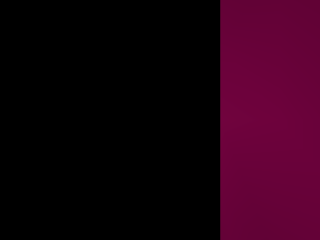

In [ ]:

#black again ince we need to forward the data
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(
        data,
        camera="emeet_c960_camera",
    )
    media.show_image(renderer.render())
